# Quality toolbox

In [1]:
# Import library needed
#import functions
import numpy as np
import matplotlib.pyplot as plt

from NEUREQUA import *


from NEUREQUA import cognitive_module as cog 
from NEUREQUA import quality_module as quality

## Load data and parameters

In [2]:
# Parameters of the session you analyze

# Name or number of the subject you analyze
sub = 'sub-97'
# Name of the session you analyze
sess = 'sess-1'

In [3]:
# Path to data - This is the only thing you have to change to run the script


# Path where your micro data are stored (.dat, .medd, .nsX, .ncs)
dataFolder=r'C:\Users\dornier\PhD\Article\NeuReQua\Analyses\Sub-97\ncs/'
#dataFolder=r'F:\Screening\database\sub-97\sess-1\ncs/' 

# Path where you want to store figures and results
saveFolder=r'C:\Users\dornier\PhD\Article\NeuReQua\Analyses\Sub-97\Quality_Metrics/'

# path to excel file for the RMS tracking, only one excel is used per patient, all RMS data for the SEEG will be trancked on a single file

trackingtbl =r'C:\Users\dornier\PhD\Article\NeuReQua\Analyses\Sub-97/Metrics_Sub-97_Sess-1.xlsx'


In [ ]:
# Load data 
# Give the path folder where the files of micro-electrodes are stored
raw_data, data = quality.load_raw_data(dataFolder,dtype='ncs',length='all',pattern2exclude='_sub.ncs')


In [ ]:
# Determine parameters from the recording
sr = int(raw_data.info['sfreq'])
print("Your recording has a sampling rate of: " + str(sr) +" Hz")

In [ ]:
duration_min  = int(raw_data.__len__()/sr/60)

print("L'enregistrement a duré : "+str(duration_min)+" minutes")

In [ ]:
# Display the name of your electrodes

chRegions = np.array(raw_data.ch_names)
print(chRegions)

In [ ]:
# Re-order channels and data if there is more than two tetrode on a shaft
chRegions, data = quality.reorder_data(chRegions,data)


print(chRegions)

In [ ]:
# Prepare the tracking file

quality.tblprep(trackingtbl,chRegions,sub,sess)

## Quality analysis of the signal

In [ ]:
# Get the power spectrum of each channel 
p_welch = quality.p_welch(data,chRegions,sub,sess,sr,sr_down=1,fr_low=1,fr_high=90,saveFolder=saveFolder,probe_type='Dixi')

In [ ]:
# Get the level of noise of the recording for each channel (not displayed in the notebook)
quality.plot_noise(data,sr,chRegions,saveFolder)


In [ ]:
# Compute RMS on filtered signal
quality.rms_signal_filtered(data,trackingtbl,chRegions,sub,sess,fr_low=300,fr_high=3000,sr=sr,saveFolder=saveFolder) 

In [ ]:
# Compute correlation between neighbouring channels

correlation = quality.correlation_coefficient(data,chRegions,saveFolder,trackingtbl,sub,sess,probe_type='Dixi')

In [ ]:
# Compute variance normalized by variance of neighbouring channels
quality.variance_normalized(data,chRegions,saveFolder,trackingtbl,sub,sess,probe_type='Dixi')

In [ ]:
quality.deviation(data,chRegions,saveFolder,trackingtbl,sub,sess,probe_type='Dixi')

In [ ]:
quality.variance(data,chRegions,saveFolder,trackingtbl,sub,sess)

In [ ]:
quality.kurtosis(data,chRegions,saveFolder,trackingtbl,sub,sess)

In [ ]:
quality.hurst_component(data,chRegions,saveFolder,trackingtbl,sub,sess)

In [ ]:
SNR = quality.signaltonoise(data,chRegions,saveFolder,trackingtbl,sub,sess)

In [ ]:
# Test on artefacts
from NEUREQUA import artefact_detections

test = list()

for iTetrode in range(int(data.shape[0]/4)):
    num_canalTetrode = (iTetrode*4,iTetrode*4+1,iTetrode*4+2,iTetrode*4+3)

    test.append(num_canalTetrode)

tetInds = test 

# Movement artefacts
badWins_movement = artefact_detections.detect_movement_artifacts(chTraces=data,chGoodInds=list(range(len(chRegions))),
                                                                tetInds=tetInds,verbose=False,SR=32768)


# Detect subtle artefacts
badWins_subtle = artefact_detections.detect_subtle_artifacts(chTraces=data,chGoodInds=np.array(list(range(len(chRegions)))),
                                                            tetInds= tetInds,chRegs=chRegions,SR=32768,verbose=False)

# Step 3: Merge detected windows using intersection
badWins_final = artefact_detections.get_timeWinsIntersect(badWins_movement, badWins_subtle, data.shape[1])


# Step 4: Print percentage of artefacted signal
artefact_detections.ratio_artefact(data,badWins_final,trackingtbl,sub,sess)

# Cognitive analyses of experiment

In [4]:
# Step 1 - Create the file with raw data
raw, metadata = cog.load_neuralynx_micro(dataFolder,sub,sess)

Found 32 .ncs file(s) in 'C:\Users\dornier\PhD\Article\NeuReQua\Analyses\Sub-97\ncs/'
Excluding channels matching pattern: '*_sub'
  → 0 macrocontact channel(s) excluded
  → 32 microwire channel(s) retained
File already exist

── Recording summary ──────────────────────────────
  Channels   : 32
  Samp. rate : 32768 Hz
  Duration   : 2929.7 s (48.83 min)
  Samples    : 96,001,104
  Data shape : (32, 96001104)  (channels × samples)
  Channel labels:
    • dtb1
    • dtb2
    • dtb3
    • dtb4
    • dtb5
    • dtb6
    • dtb7
    • dtb8
    • dtp1
    • dtp2
    • dtp3
    • dtp4
    • dtp5
    • dtp6
    • dtp7
    • dtp8
    • vb1
    • vb2
    • vb3
    • vb4
    • vb5
    • vb6
    • vb7
    • vb8
    • vtp1
    • vtp2
    • vtp3
    • vtp4
    • vtp5
    • vtp6
    • vtp7
    • vtp8
───────────────────────────────────────────────────



c:\Users\dornier\GitHub\NEUREQUA\NEUREQUA\cognitive_module.py:120: UserWarning: Unable to parse original file path from Neuralynx header: -FileType Event
  warnings.warn('Unable to parse original file path from Neuralynx header: ' + hdr_lines[1])
c:\Users\dornier\GitHub\NEUREQUA\NEUREQUA\cognitive_module.py:172: UserWarning: Unable to parse time string from Neuralynx header: -FileVersion 3.2
  warnings.warn('Unable to parse time string from Neuralynx header: ' + time_string)
c:\Users\dornier\GitHub\NEUREQUA\NEUREQUA\cognitive_module.py:172: UserWarning: Unable to parse time string from Neuralynx header: -FileUUID ea1efbb1-18e4-46d9-947a-72a17526a4cc
  warnings.warn('Unable to parse time string from Neuralynx header: ' + time_string)
c:\Users\dornier\GitHub\NEUREQUA\NEUREQUA\cognitive_module.py:134: UserWarning: Unable to parse parameter line from Neuralynx header: -TimeCreated 2023/03/28 11:40:20
  warnings.warn('Unable to parse parameter line from Neuralynx header: ' + line)
c:\Users\

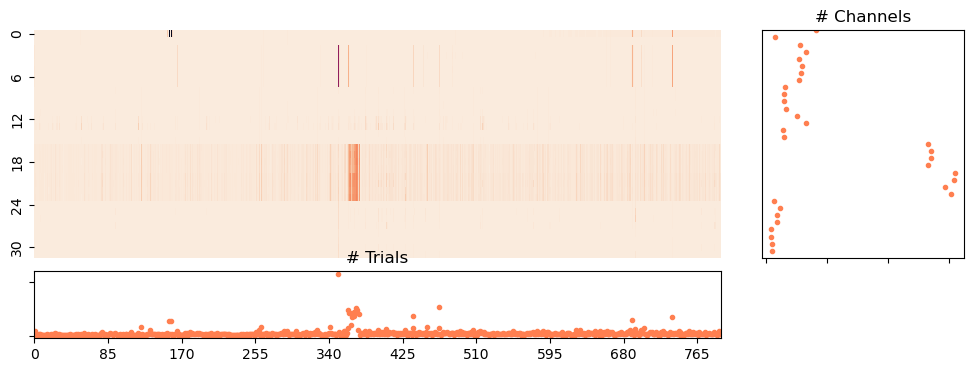

In [5]:
cog.plot_artefact_map(dataFolder,sub,sess)

In [6]:
cog.plot_erp(dataFolder,metadata,sub,sess)

c:\Users\dornier\GitHub\NEUREQUA\NEUREQUA\cognitive_module.py:120: UserWarning: Unable to parse original file path from Neuralynx header: -FileType Event
  warnings.warn('Unable to parse original file path from Neuralynx header: ' + hdr_lines[1])
c:\Users\dornier\GitHub\NEUREQUA\NEUREQUA\cognitive_module.py:172: UserWarning: Unable to parse time string from Neuralynx header: -FileVersion 3.2
  warnings.warn('Unable to parse time string from Neuralynx header: ' + time_string)
c:\Users\dornier\GitHub\NEUREQUA\NEUREQUA\cognitive_module.py:172: UserWarning: Unable to parse time string from Neuralynx header: -FileUUID ea1efbb1-18e4-46d9-947a-72a17526a4cc
  warnings.warn('Unable to parse time string from Neuralynx header: ' + time_string)
c:\Users\dornier\GitHub\NEUREQUA\NEUREQUA\cognitive_module.py:134: UserWarning: Unable to parse parameter line from Neuralynx header: -TimeCreated 2023/03/28 11:40:20
  warnings.warn('Unable to parse parameter line from Neuralynx header: ' + line)
c:\Users\